# OP26 — Phase 3: Demand Prediction Agent
Forecasts, **one hour ahead** per zone: utilization, expected load (energy), and **congestion probability** P(util ≥ 0.80). Logic in `demand.py`.

**Leakage-safe:** the target is the value at hour *t*; every feature is strictly pre-*t* (lags / rolling) or deterministic for *t* (calendar / static zone attributes). Contemporaneous outcomes (occupancy, energy, revenue, price at *t*) are never used. Validation is a strict **time-based split** — the final 4 days are the untouched test set. Gradient boosting = sklearn HistGradientBoosting (same GBM family as LightGBM, available offline).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display
import config as C, demand as D
train, test = D.load_split()
print('train rows', len(train), '| test rows', len(test),
      f'| test = hour_index >= {D.TEST_START} (final {720-D.TEST_START}h / 4 days)')

train rows 112632 | test rows 23712 | test = hour_index >= 624 (final 96h / 4 days)


## Train all three heads, score, and write outputs
`D.run()` fits the utilization regressor, the energy (load) regressor, and the congestion classifier; computes baselines; and writes predictions, metrics, per-zone metrics, feature importance, models, and figures.

In [2]:
metrics, preds, fi, by_zone = D.run()
# headline metrics
piv = (metrics[metrics.target=='utilization']
       .pivot(index='model', columns='metric', values='value')
       .sort_values('RMSE'))
display(piv)
print('Energy load  :', metrics[(metrics.target=='energy_kwh')&(metrics.model=='GBM')]
      .set_index('metric').value.round(3).to_dict())
print('Congestion   :', metrics[(metrics.target=='congestion')&(metrics.model=='GBM')]
      .set_index('metric').value.round(3).to_dict())

metric,MAE,R2,RMSE
model,,,
GBM,0.02135,0.95904,0.03562
persistence_1h,0.02717,0.91174,0.05228
climatology,0.06222,0.74286,0.08924
seasonal_weekly,0.06549,0.70230,0.09602
seasonal_daily,0.06849,0.65535,0.10332


Energy load  : {'RMSE': 216.739, 'MAE': 65.892, 'R2': 0.971}
Congestion   : {'ROC_AUC': 0.992, 'avg_precision': 0.807, 'Brier': 0.007, 'base_rate': 0.01}


**Result:** the GBM beats every baseline on utilization (incl. a strong 1-hour persistence), explains ~97% of load variance, and detects the rare >80% congestion events with high AUC. Recent lags + the weekly lag + zone identity dominate — consistent with the Phase-2 seasonality.

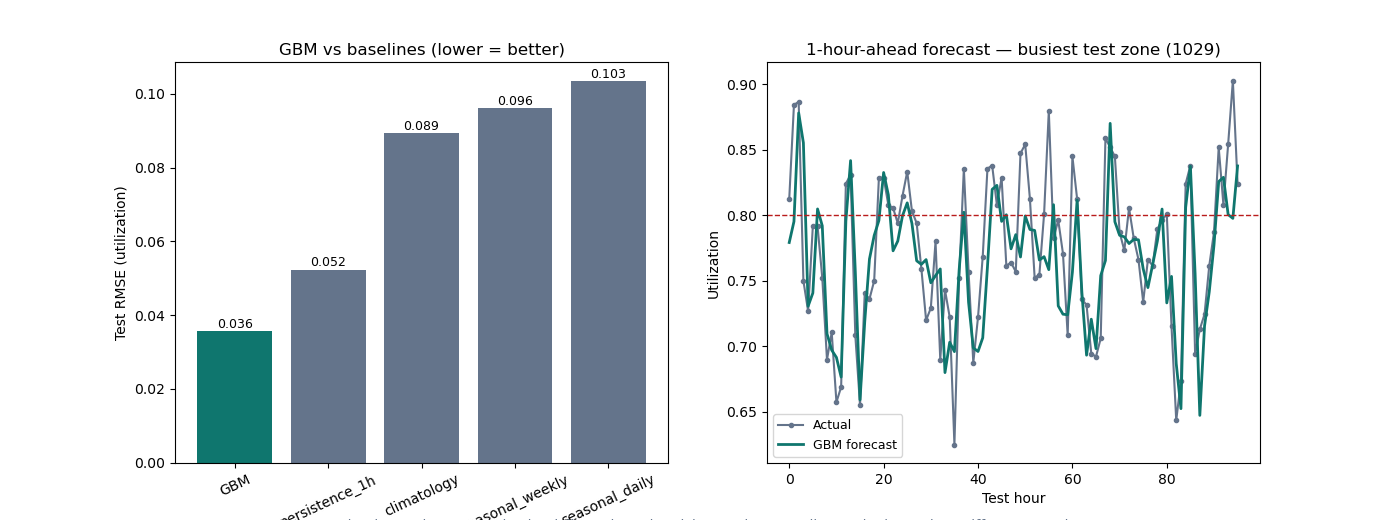

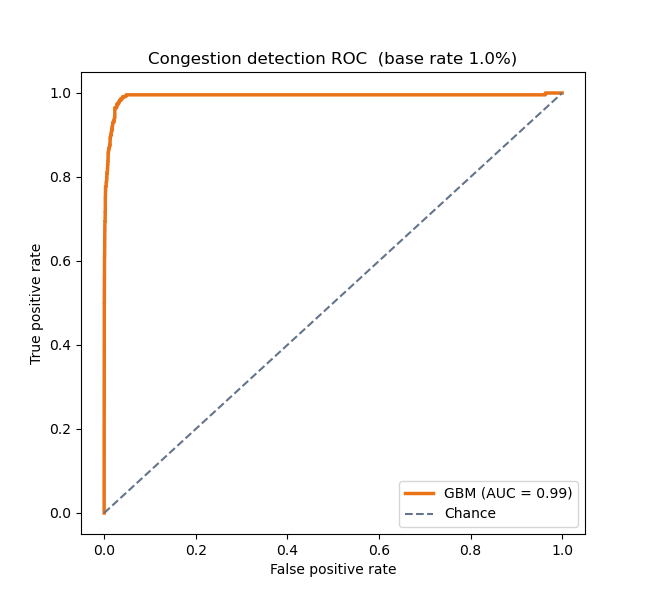

In [3]:
display(Image(C.FIG_DIR/'fig09_demand_pred.png'))
display(Image(C.FIG_DIR/'fig11_congestion_roc.png'))

## Per-zone performance & feature importance

per-zone GBM utilization: median R2 = 0.894 | mean RMSE = 0.0291 | zones R2<0: 3


,zone,RMSE,MAE,R2,n,util_mean
178,1029,0.041175,0.031705,0.517790,96.0,0.773679
104,715,0.083646,0.068608,0.846799,96.0,0.758681
59,570,0.058763,0.035823,0.953874,96.0,0.692460
206,1098,0.099648,0.085226,-0.067582,96.0,0.653329
170,991,0.039438,0.029835,0.859407,96.0,0.619226
110,732,0.022970,0.018161,0.577231,96.0,0.608285
0,102,0.039811,0.026750,0.823233,96.0,0.592622
53,522,0.019508,0.014504,0.981997,96.0,0.589094


,feature,importance,std
0,util_lag1,0.18499,0.00115
1,util_lag2,0.01043,0.00031
4,util_lag168,0.00970,0.00036
26,zone,0.00895,0.00031
3,util_lag24,0.00402,0.00009
17,hour_cos,0.00368,0.00030
13,hour,0.00175,0.00009
5,energy_lag1,0.00173,0.00008
8,energy_lag24,0.00144,0.00009
16,hour_sin,0.00121,0.00008


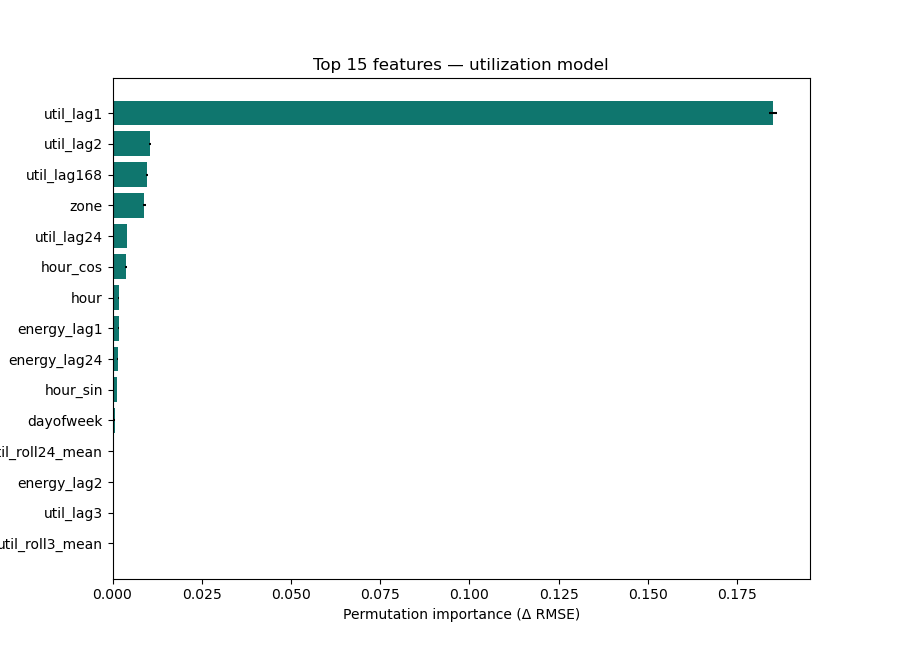

In [4]:
print('per-zone GBM utilization: median R2 = %.3f | mean RMSE = %.4f | zones R2<0: %d'
      % (by_zone.R2.median(), by_zone.RMSE.mean(), (by_zone.R2<0).sum()))
display(by_zone.sort_values('util_mean', ascending=False).head(8))
display(fi.head(10))
display(Image(C.FIG_DIR/'fig10_feature_importance.png'))

---
**Phase 3 complete.** `demand_predictions.csv` (forecast utilization + congestion probability per zone-hour) is the direct input to **Phase 4 — the Tariff Pricing Agent**.